# Generate Image

## Prepare Reference

Load the wing-up and wing-down reference images, resize and center-crop each one to 1536 x 2048, save the resized images, preview them, and save a combined reference image for later processing.

In [1]:
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

from origami_texturing.paths import INPUTS_DIR, PROCESSED_DATA_DIR

wingup_path = INPUTS_DIR / "wingup.png"
wingdown_path = INPUTS_DIR / "wingdown.png"
resized_wingup_path = PROCESSED_DATA_DIR / "resized-wingup.png"
resized_wingdown_path = PROCESSED_DATA_DIR / "resized-wingdown.png"

REFERENCE_IMAGE_SIZE = (1536, 2048)


def load_reference_image(path):
    with Image.open(path) as image:
        return ImageOps.fit(
            image.convert("RGBA"),
            REFERENCE_IMAGE_SIZE,
            method=Image.Resampling.LANCZOS,
            centering=(0.5, 0.5),
        )

Saved resized image to: C:\Users\morph\GitHub\origami-texturing\data\processed\resized-wingup.png
Saved resized image to: C:\Users\morph\GitHub\origami-texturing\data\processed\resized-wingdown.png


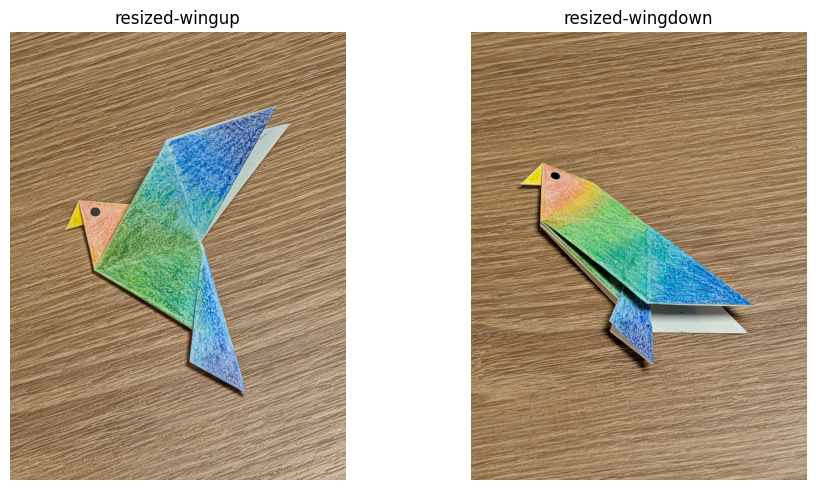

In [2]:
wingup = load_reference_image(wingup_path)
wingdown = load_reference_image(wingdown_path)

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
wingup.save(resized_wingup_path)
wingdown.save(resized_wingdown_path)

print(f"Saved resized image to: {resized_wingup_path}")
print(f"Saved resized image to: {resized_wingdown_path}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, image, title in (
    (axes[0], wingup, "resized-wingup"),
    (axes[1], wingdown, "resized-wingdown"),
):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()

Saved resized pair image to: C:\Users\morph\GitHub\origami-texturing\data\processed\resized-pair.png


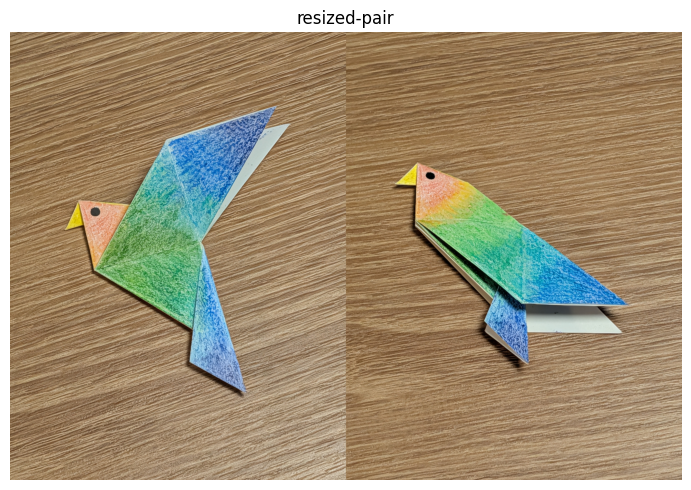

In [3]:
combined_width = wingup.width + wingdown.width
combined_height = max(wingup.height, wingdown.height)

pair = Image.new("RGBA", (combined_width, combined_height), (255, 255, 255, 0))
pair.paste(wingup, (0, (combined_height - wingup.height) // 2), wingup)
pair.paste(wingdown, (wingup.width, (combined_height - wingdown.height) // 2), wingdown)

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
pair_path = PROCESSED_DATA_DIR / "resized-pair.png"
pair.save(pair_path)

print(f"Saved resized pair image to: {pair_path}")

plt.figure(figsize=(10, 5))
plt.imshow(pair)
plt.title("resized-pair")
plt.axis("off")
plt.tight_layout()

## Generate Pattern

Generate an origami pattern image from the pair image and mask-pair image with the OpenAI Images API.

In [4]:
import base64
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

from origami_texturing import get_openai_client
from origami_texturing.paths import PROCESSED_DATA_DIR, RAW_DATA_DIR

pair_path = PROCESSED_DATA_DIR / "resized-pair.png"
mask_pair_path = RAW_DATA_DIR / "dove-pair-mask.png"
generated_pair_path = PROCESSED_DATA_DIR / "generated-pair.png"

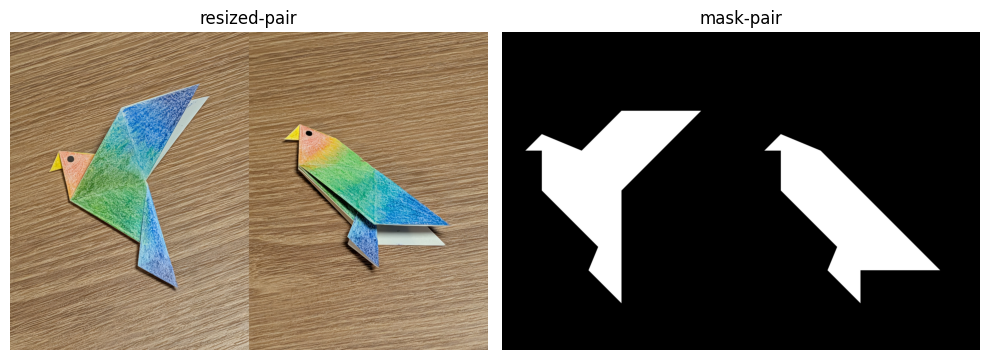

In [5]:
for path in (pair_path, mask_pair_path):
    if not path.exists():
        raise FileNotFoundError(path)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, path, title in (
    (axes[0], pair_path, "resized-pair"),
    (axes[1], mask_pair_path, "mask-pair"),
):
    ax.imshow(Image.open(path))
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()

In [6]:
ORIGAMI_PATTERN_EXTRACT_PROMPT = """
Transfer only the pattern from the origami in the pair image into the white silhouette area of the mask-pair image.
Preserve colors, textures, and visual details of the origami's pattern, while removing only shadow and shade. 
Return a PNG-style image with a black background.
""".strip()


def generate_origami_pattern(
    mask_path: str | Path,
    reference_path: str | Path,
    output_path: str | Path,
    model: str = "gpt-image-2",
    size: str = "1536x1024",
    quality: str = "low",
) -> Path:
    mask_path = Path(mask_path)
    reference_path = Path(reference_path)
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    client = get_openai_client()

    with mask_path.open("rb") as mask_file, reference_path.open("rb") as reference_file:
        result = client.images.edit(
            model=model,
            image=[mask_file, reference_file],
            prompt=ORIGAMI_PATTERN_EXTRACT_PROMPT,
            size="1536x1024",
            quality="low",
            output_format="png",
        )

    b64_json = result.data[0].b64_json
    if b64_json is None:
        raise RuntimeError("OpenAI image edit response did not include b64_json image data.")

    output_path.write_bytes(base64.b64decode(b64_json))
    return output_path

Saved generated pattern image to: C:\Users\morph\GitHub\origami-texturing\data\processed\generated-pair.png


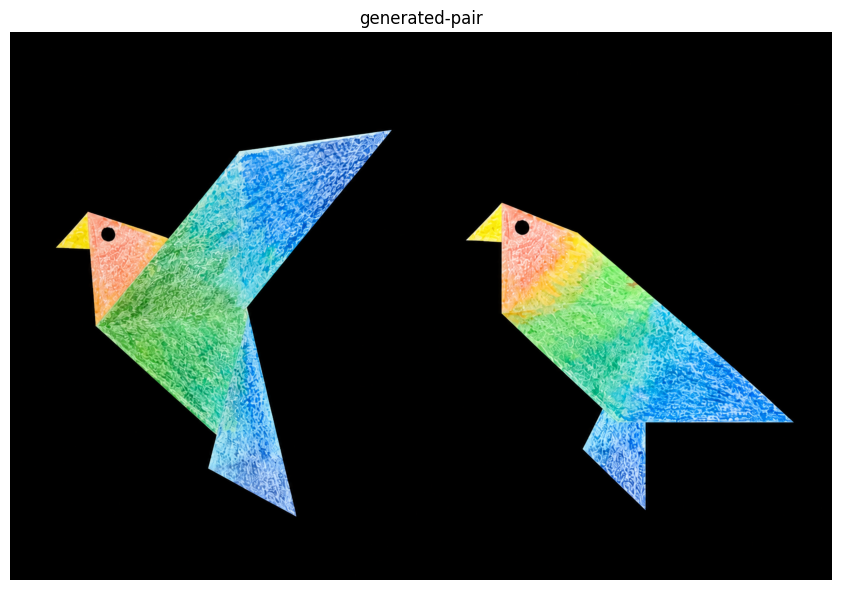

In [7]:
generated_path = generate_origami_pattern(
    mask_path=mask_pair_path,
    reference_path=pair_path,
    output_path=generated_pair_path,
)

print(f"Saved generated pattern image to: {generated_path}")

generated = Image.open(generated_path)

plt.figure(figsize=(10, 6))
plt.imshow(generated)
plt.title("generated-pair")
plt.axis("off")
plt.tight_layout()

## Post-Process Pattern

Split the generated pair into wing-up and wing-down images, remove the background with `rembg`, and save transparent PNGs to `data/processed`.

In [8]:
import matplotlib.pyplot as plt
from PIL import Image
from rembg import remove

from origami_texturing.paths import PROCESSED_DATA_DIR

generated_pair_path = PROCESSED_DATA_DIR / "generated-pair.png"
generated_wingup_path = PROCESSED_DATA_DIR / "generated-wingup.png"
generated_wingdown_path = PROCESSED_DATA_DIR / "generated-wingdwon.png"

Loaded generated-pair.png: 1536x1024


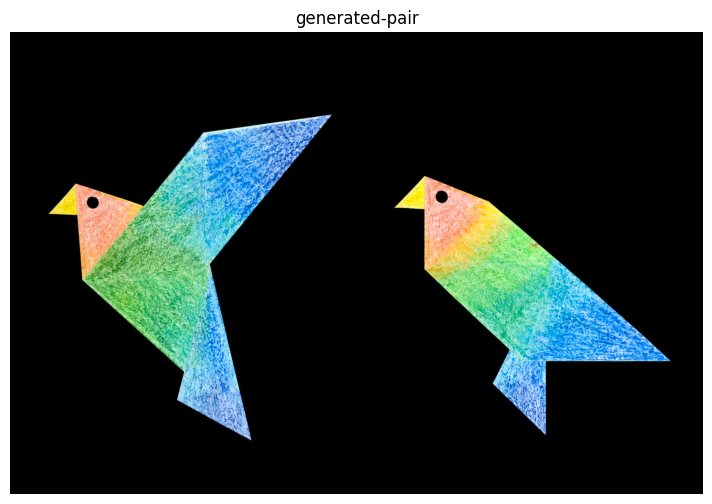

In [9]:
generated_pair = Image.open(generated_pair_path).convert("RGBA")
width, height = generated_pair.size

print(f"Loaded {generated_pair_path.name}: {width}x{height}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(generated_pair)
ax.set_title("generated-pair")
ax.axis("off")
plt.show()

generated-wingup-raw: (768, 1024)
generated-wingdwon-raw: (768, 1024)


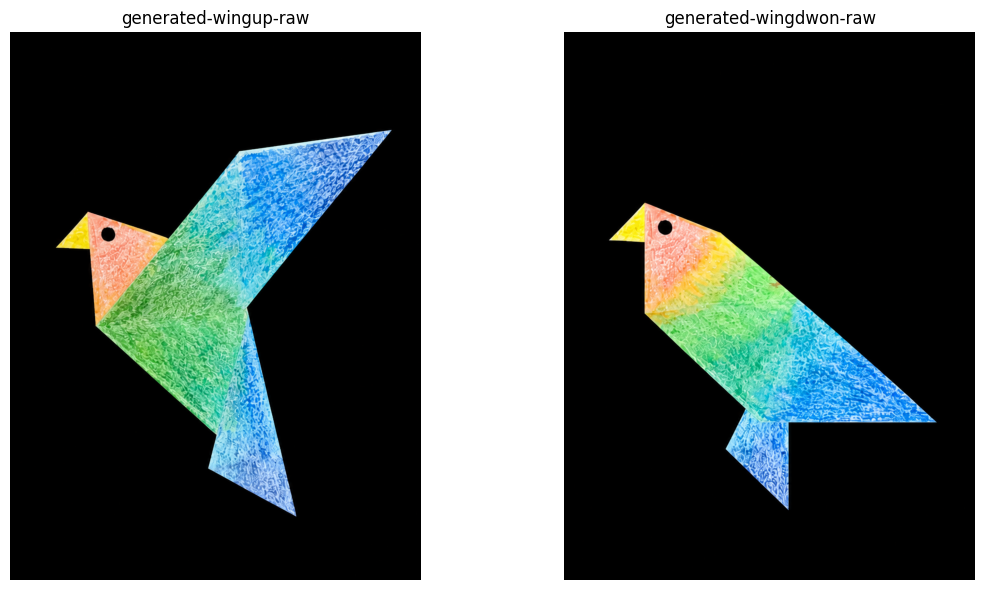

In [10]:
mid_x = width // 2

generated_wingup_raw = generated_pair.crop((0, 0, mid_x, height))
generated_wingdown_raw = generated_pair.crop((mid_x, 0, width, height))

print(f"generated-wingup-raw: {generated_wingup_raw.size}")
print(f"generated-wingdwon-raw: {generated_wingdown_raw.size}")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(generated_wingup_raw)
axes[0].set_title("generated-wingup-raw")
axes[0].axis("off")
axes[1].imshow(generated_wingdown_raw)
axes[1].set_title("generated-wingdwon-raw")
axes[1].axis("off")
plt.tight_layout()
plt.show()

Saved C:\Users\morph\GitHub\origami-texturing\data\processed\generated-wingup.png
Saved C:\Users\morph\GitHub\origami-texturing\data\processed\generated-wingdwon.png


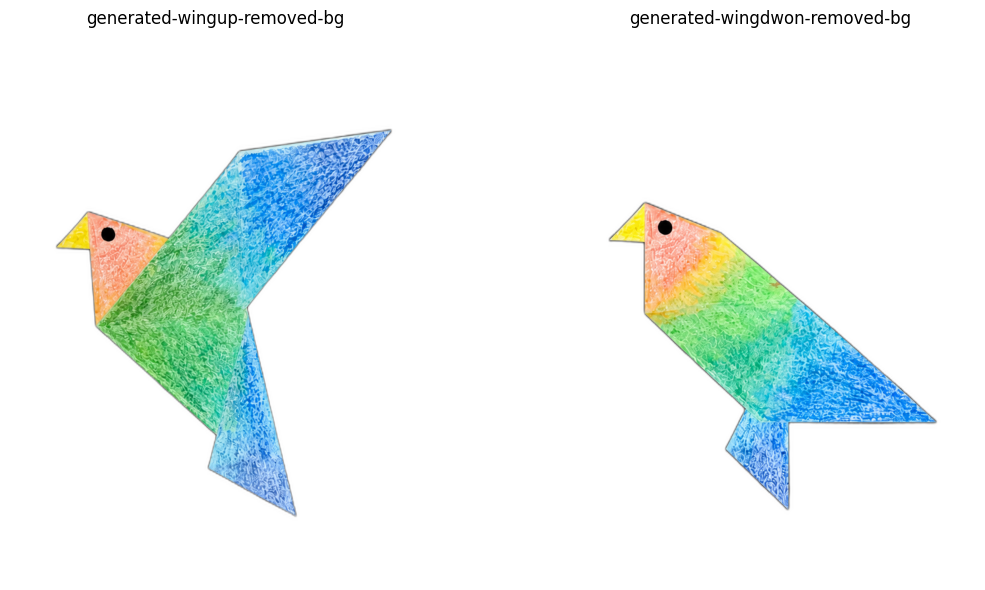

In [11]:
generated_wingup = remove(generated_wingup_raw).convert("RGBA")
generated_wingdown = remove(generated_wingdown_raw).convert("RGBA")

generated_wingup_white_bg = Image.alpha_composite(
    Image.new("RGBA", generated_wingup.size, (255, 255, 255, 255)),
    generated_wingup,
)
generated_wingdown_white_bg = Image.alpha_composite(
    Image.new("RGBA", generated_wingdown.size, (255, 255, 255, 255)),
    generated_wingdown,
)

generated_wingup.save(generated_wingup_path)
generated_wingdown.save(generated_wingdown_path)

print(f"Saved {generated_wingup_path}")
print(f"Saved {generated_wingdown_path}")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(generated_wingup_white_bg)
axes[0].set_title("generated-wingup-removed-bg")
axes[0].axis("off")
axes[1].imshow(generated_wingdown_white_bg)
axes[1].set_title("generated-wingdwon-removed-bg")
axes[1].axis("off")
plt.tight_layout()
plt.show()